<a href="https://colab.research.google.com/github/Insight-Syndicate/DSPL_GCW/blob/main/Models/KNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import Necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import auth
from googleapiclient.discovery import build

In [ ]:
# Authenticate and build Google Drive API service
auth.authenticate_user()
drive_service = build('drive', 'v3')

# Public Google Drive folder and file name
folder_id = "1XkRUF4MCrgqzis3v2C7Bx9GQaK5XgFZI"
file_name = "clean_train.csv"

# Search for the file
results = drive_service.files().list(q=f"'{folder_id}' in parents and name='{file_name}'",

                                     fields="files(id)").execute()
files = results.get("files", [])

if files:
    clean_train = pd.read_csv(f"https://drive.google.com/uc?id={files[0]['id']}")
    print(clean_train)
else:
    print(f"'{file_name}' not found in the folder.")

        Customer_ID outlet_city  luxury_sales  fresh_sales  dry_sales  \
0        10493832.0    Kelaniya       1209.60       756.00    5292.00   
1        10178643.0    Moratuwa       1590.12      1060.08    6007.12   
2        10513916.0     Wattala       2288.88      1481.04    9155.52   
3        10334589.0     Wattala       2274.94      1739.66    9099.76   
4        10458365.0    Kelaniya       2345.49      2069.55    9243.99   
...             ...         ...           ...          ...        ...   
774140   10197979.0     Gampaha       3893.40      3893.40    3448.44   
774141   10494575.0  Katunayake       6095.86      5557.99    6275.15   
774142   10565682.0     Colombo       5121.42      4820.16    4669.53   
774143   10351977.0       Kandy       6311.76      6311.76    5940.48   
774144   10637635.0     Negombo       5833.50      6027.95    6611.30   

        cluster_catgeory  outlet_city_encoded  
0                      4                   11  
1                      1   

# **Data Scaling**

## **Train**

We are using the robust scaller since our data is skewed and luxury sales has outliers. Since this technique scales using the median and IQR it is best suited to deal with the skewness and the extreme values.

In [ ]:
from sklearn.preprocessing import RobustScaler
# Identify numerical columns
numerical_columns = ['luxury_sales', 'fresh_sales', 'dry_sales']

# Initialize RobustScaler
DSPL_scaler = RobustScaler()

# Fit on training numerical data and transform both train & test
clean_train[numerical_columns] = DSPL_scaler.fit_transform(clean_train[numerical_columns])
clean_train

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory,outlet_city_encoded
0,10493832.0,Kelaniya,-0.449457,-0.514864,0.291089,4,11
1,10178643.0,Moratuwa,-0.111244,-0.454663,0.424165,1,13
2,10513916.0,Wattala,0.509826,-0.371322,1.010049,4,19
3,10334589.0,Wattala,0.497436,-0.320120,0.999672,4,19
4,10458365.0,Kelaniya,0.560142,-0.254809,1.026512,4,11
...,...,...,...,...,...,...,...
774140,10197979.0,Gampaha,1.935952,0.106275,-0.051979,3,4
774141,10494575.0,Katunayake,3.893537,0.435829,0.474042,3,10
774142,10565682.0,Colombo,3.027438,0.289754,0.175253,3,1
774143,10351977.0,Kandy,4.085433,0.585060,0.411764,3,9


#**KNN Model**

In [ ]:
#Importing relevant libraries
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
#X, Y split
X = clean_train[['luxury_sales','fresh_sales','dry_sales','outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [ ]:
from sklearn.model_selection import train_test_split
# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

To optimize KNN model we need to find the n_neighbours and this is done by making use of the gridsearchCV system.

In [ ]:
from sklearn.model_selection import GridSearchCV
#Define the parameter grid for n_neighbors
param_grid = {'n_neighbors': list(range(1, 10))}

#Create and fit the GridSearchCV object
grid = GridSearchCV(KNeighborsClassifier(algorithm='auto'), param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

#Get the best n_neighbors value
best_k = grid.best_params_['n_neighbors']
print(f"Best k value: {best_k}")

Best k value: 5


In [ ]:
# Initialize KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the classifier using the scaled training data (X_train, y_train)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

# Predict labels for the test set
y_pred = knn_model.predict(X_test)

MSE = mean_squared_error(y_test, y_pred)
r2_ = r2_score(y_test, y_pred)
Acs = accuracy_score(y_test, y_pred)

print(f"MSE: {MSE}")
print(f"R2: {r2_}")
print(f"Accuracy: {Acs}")

MSE: 0.0012207015481595824
R2: 0.9996505485490482
Accuracy: 0.9997739441577482


[[37871     2     1     1     0     1]
 [    2 30915     0     2     2     1]
 [    0     0  9744     0     2     2]
 [    0     0     1 34365     4     0]
 [    0     1     1     1  7958     1]
 [    0     0     5     3     2 33941]]


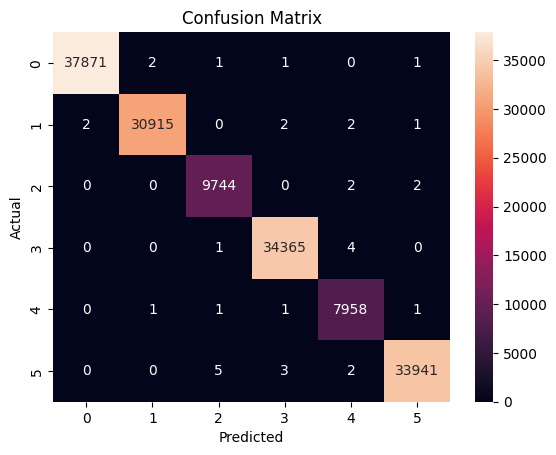

In [ ]:
#Create a confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     37876
           2       1.00      1.00      1.00     30922
           3       1.00      1.00      1.00      9748
           4       1.00      1.00      1.00     34370
           5       1.00      1.00      1.00      7962
           6       1.00      1.00      1.00     33951

    accuracy                           1.00    154829
   macro avg       1.00      1.00      1.00    154829
weighted avg       1.00      1.00      1.00    154829



Distribution of Predicted Clusters:
{np.int64(1): np.int64(37873), np.int64(2): np.int64(30918), np.int64(3): np.int64(9752), np.int64(4): np.int64(34372), np.int64(5): np.int64(7968), np.int64(6): np.int64(33946)}


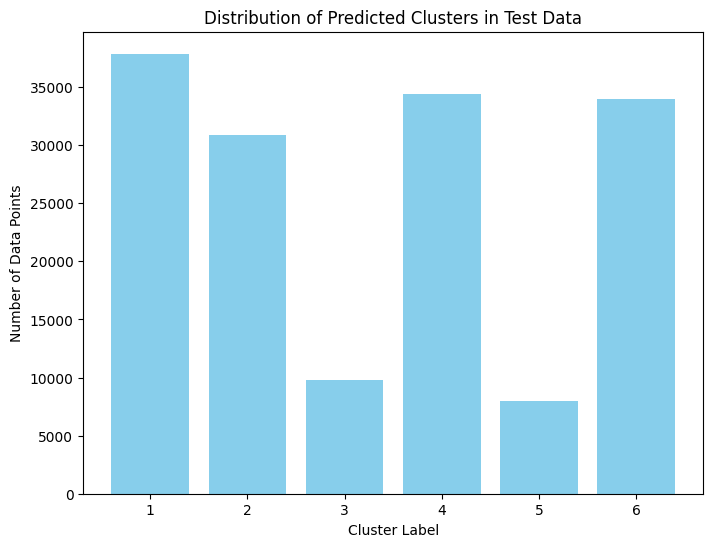

In [ ]:
# Analyze the distribution of predicted clusters
unique, counts = np.unique(y_pred, return_counts=True)
cluster_dist = dict(zip(unique, counts))

print("Distribution of Predicted Clusters:")
print(cluster_dist)

# Visualize the distribution
plt.figure(figsize=(8, 6))
plt.bar(cluster_dist.keys(), cluster_dist.values(), color='skyblue')
plt.xlabel("Cluster Label")
plt.ylabel("Number of Data Points")
plt.title("Distribution of Predicted Clusters in Test Data")
plt.show()

## **Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error

# Predict on training, validation, and test sets
y_train_pred = knn_model.predict(X_train)
y_val_pred = knn_model.predict(X_val)
y_test_pred = knn_model.predict(X_test)

# Calculate accuracy and MSE for training, validation, and test sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Print the results
print(f"Training Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"Training MSE: {train_mse:.4f}, Validation MSE: {val_mse:.4f}, Test MSE: {test_mse:.4f}")

# Detect overfitting or underfitting
if train_accuracy > val_accuracy + 0.005:
    print("The model is overfitting.")
elif train_accuracy < 0.90 and val_accuracy < 0.90:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Training Accuracy: 0.9997, Validation Accuracy: 0.9998, Test Accuracy: 0.9998
Training MSE: 0.0017, Validation MSE: 0.0010, Test MSE: 0.0012
The model is well-fitted.


In [ ]:
# Checking how well the model distinguish between classes
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarizing the labels (since it's multi-class)
y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4, 5, 6])

y_pred_probs = knn_model.predict_proba(X_test)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test_bin, y_pred_probs, average='macro', multi_class='ovr')
print(f"ROC-AUC: {roc_auc}")

ROC-AUC: 0.9998529257218097


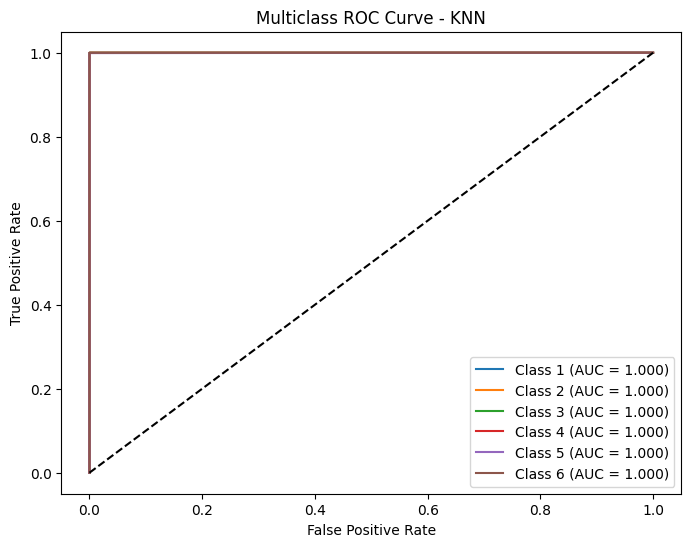

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Convert y_test to a binarized format (One-vs-Rest)
y_val_binarized = label_binarize(y_val, classes=knn_model.classes_)

# Get probability scores for all classes using X_val
y_probs = knn_model.predict_proba(X_val)

# Plot ROC Curve for each class
plt.figure(figsize=(8, 6))

for i in range(y_val_binarized.shape[1]):  # Loop through each class
    fpr, tpr, _ = roc_curve(y_val_binarized[:, i], y_probs[:, i])
    auc_score = roc_auc_score(y_val_binarized[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, label=f'Class {knn_model.classes_[i]} (AUC = {auc_score:.3f})')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - KNN')
plt.legend()
plt.show()